In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray as xr
import xesmf as xe

module_path = os.path.abspath(os.path.join('..', 'MultiThread_Model'))
if module_path not in sys.path:
    sys.path.append(module_path)
from subs1_utils import *


warnings.filterwarnings("ignore")

# Model Variables
In the following cell you can set the values of the variables relevant to the model. The details of each variable are included in the README. In most cases it is only necessary to set values for the standard variables.

In [2]:
# Define Spectral Truncation Desired and Consistent Gausian Grid.
zw = 63
kmax = 26

In [3]:
# Check value for kmax.
if kmax != 11 and kmax != 26:
    raise Exception("Unexpected value for kmax: " + str(kmax))

# Check value for zw.
# Afterwards, set mw, jmax, and imax values based on
# the value given to zw.
match zw:
    case 42:
        mw = zw
        jmax = 64
        imax = 128
    case 63:
        mw = zw
        jmax = 96
        imax = 192
    case 124:
        mw = zw
        jmax = 188
        imax = 376
    case _:
        raise Exception("Unexpected value for zw: " + str(zw))

In [4]:
# Create and return a path in which to save the preprocess output files.
preprocess_path = set_preprocess_path(zw, kmax)

# Setup necessary element for interpolation onto model Gaussian Grid.
cost_lg, wlg, lats, lons, vsht, dsht, disht, dvsht, divsht = \
    set_spectral_transforms(jmax, imax, mw, zw)
dlatlon = xr.Dataset({"lat": lats, "lon": lons})

preprocess_path = preprocess__zw_63__kmax_26/
fullpath =  /Users/bmapes/GitHub/Atmospheric-Teleconnection-Model/HeldSuarez/preprocess__zw_63__kmax_26/


In [5]:
# Get Topography Data.
topog_file = '../TopogData/topog.gridded.nc'
ds_topog = xr.open_mfdataset(topog_file)
ds_topog

<xarray.Dataset>
Dimensions:  (lat: 374, lon: 748)
Coordinates:
  * lat      (lat) float64 89.63 89.16 88.68 88.2 ... -88.2 -88.68 -89.16 -89.63
  * lon      (lon) float64 0.0 0.4813 0.9626 1.444 ... 358.1 358.6 359.0 359.5
Data variables:
    topog    (lat, lon) float32 dask.array<chunksize=(374, 748), meta=np.ndarray>

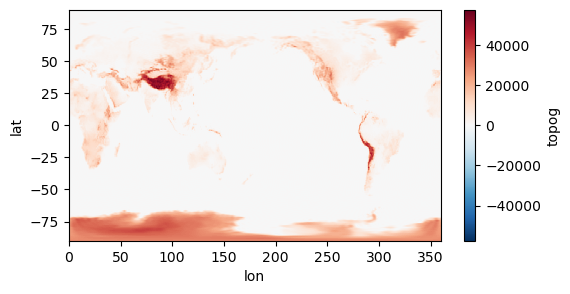

In [48]:
ds_topog.topog.plot(size=3, aspect=2);

In [7]:
regridder_topog = xe.Regridder(ds_topog, dlatlon, 'bilinear')

In [8]:
topog_gg = regridder_topog(ds_topog.topog)

In [9]:
topog_gg_dev = torch.from_numpy(np.where(topog_gg < 0.0, 0.0, topog_gg))
coeffs = dsht(topog_gg_dev)
topog_gg_r = disht(coeffs)

In [10]:
# Write out the spectral coefficients for topography to be read by
# the AGCM as a pickle file.
torch.save(coeffs, preprocess_path+'topog.spectral.pt')

In [11]:
# Now generature the vertical strucuture of temperature
# will neeed model vertical structure (si(kmax)).

delsig, si, sl, sikap, slkap, cth1, cth2, r1b, r2b = bscst(kmax)

temp_spec = torch.from_numpy(np.zeros((12, kmax, zw, mw)))
temp_gg = np.zeros((12, kmax, jmax, imax))

# Radiative equilibrium temperature
#   varying surface temperature decreasing with
#   height with a lapse rate dTe/dz approx = -rlaps degrees/m
#   to a stratospheric temperature of tstrat.

rlaps = 6.8 * 1.0e-03
h0 = 8.2e+03
tstrat = 205.0 # Fixed stratospheric temperature.
deltemp = 60.0 # pole_to_equator temperature difference.
deltheta = 10.0 # Troposphere depth in theta coords, pretty small
kappa = 2.0 / 7.0

# Set Radiative Temperature Profile here.
# k=sigma, j=lat, i=lon
# Need to use topography to reduce temperature based on altitude.
# Calculate the radiative surface temperature as a function of latitude.
temp_gg = np.zeros((kmax, jmax, imax))
sinlat = np.sin(lats * np.pi / 180.0)
coslat = np.cos(lats * np.pi / 180.0)

for j in range(jmax):
    for k in range(kmax):
        temp_gg[k, j, :] = (
            315.0 - deltemp*sinlat[j]*sinlat[j]
            - deltheta*np.log(sl[k])*coslat[j]*coslat[j])*(sl[k]**kappa)

temp_gg = np.where(temp_gg < 200.0, 200.0, temp_gg)

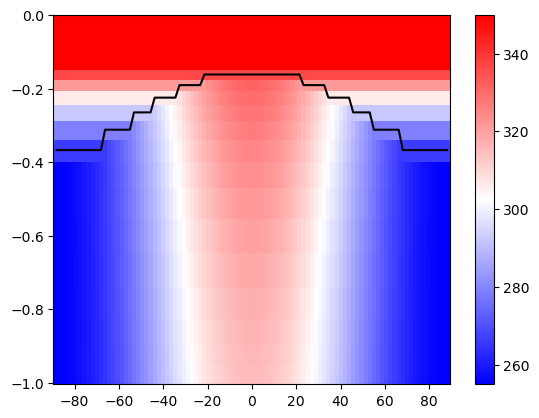

In [52]:
# Potential temperature view, tropopause is where T<= 200K

theta_gg = temp_gg * sl[:, np.newaxis, np.newaxis]**(-kappa)

Lat, Zlev = np.meshgrid(lats, -sl)
plt.pcolormesh(Lat, Zlev, theta_gg[:, :, 96], vmax=350, cmap='bwr')
plt.colorbar();
plt.contour(Lat, Zlev, temp_gg[:, :, 96], levels=[200], colors='k');

In [54]:
sl

array([0.0011232 , 0.00505616, 0.01162568, 0.0216051 , 0.03492528,
       0.05086259, 0.06788822, 0.08335917, 0.09845649, 0.11621708,
       0.13711157, 0.16169278, 0.1906111 , 0.22463262, 0.26465712,
       0.31174359, 0.36723614, 0.43240951, 0.5089765 , 0.59917282,
       0.69574045, 0.78694997, 0.86668817, 0.92940448, 0.97046364,
       0.99253296])

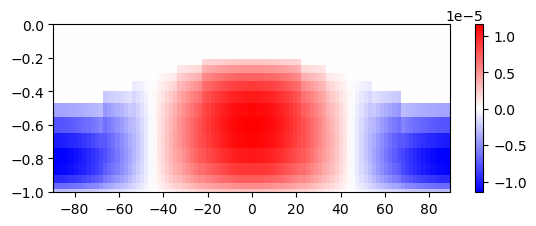

In [107]:
# Contrive a heating Q(lat,sl) # sl,k =sigma level, j=lat, i=lon 

Qmag = 1. / 86400.  # Q max K per second in dT/dt units (T not theta)
Qsurf = 0.25         # FRACTION of mid-trop Qmax that exists at surface 

Q = np.zeros((kmax, jmax)) # Right sized container

cos2lat = np.cos(2*lats * np.pi / 180.0)

for j in range(jmax): # Latitude loop 
    k_idx = np.where(temp_gg[:, j, 0] > 200)[0]  # Get indices of troposphere
    N = len(k_idx)                               # Depth of troposphere 
    i = np.arange(N)                             # index within troposphere
    Q[k_idx, j] = Qmag * cos2lat[j] * np.sin(i/(N - 1) * (np.pi-np.arcsin(Qsurf)) )   

# Check it 
Lat, Zlev = np.meshgrid(lats, -sl)
plt.subplot(211); plt.pcolormesh(Lat, Zlev, Q, cmap='bwr')
plt.colorbar();

In [67]:
trop_top = np.where(temp_gg[:, 0, 0] > 200)[0][0]

sl[trop_top:]

array([0.43240951, 0.5089765 , 0.59917282, 0.69574045, 0.78694997,
       0.86668817, 0.92940448, 0.97046364, 0.99253296])

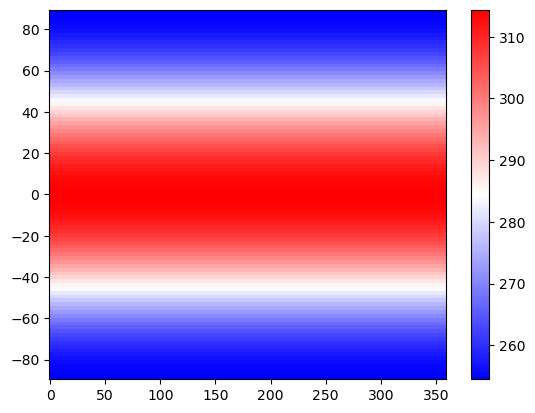

In [22]:
Lon, Lat = np.meshgrid(lons, lats)
plt.pcolormesh(Lon, Lat, temp_gg[kmax-1, :, :], cmap='bwr')
plt.colorbar();

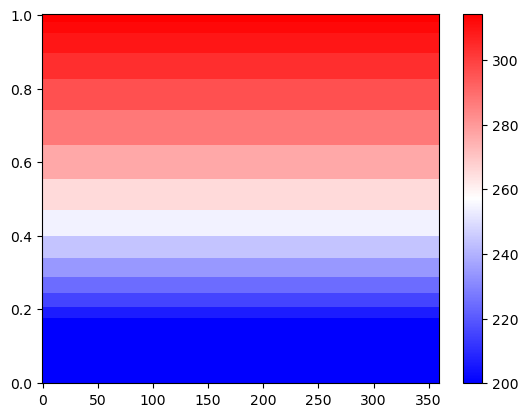

In [13]:
Lon, Zlev = np.meshgrid(lons, sl)
plt.pcolormesh(Lon, Zlev, temp_gg[:, 48, :], cmap='bwr')
plt.colorbar();

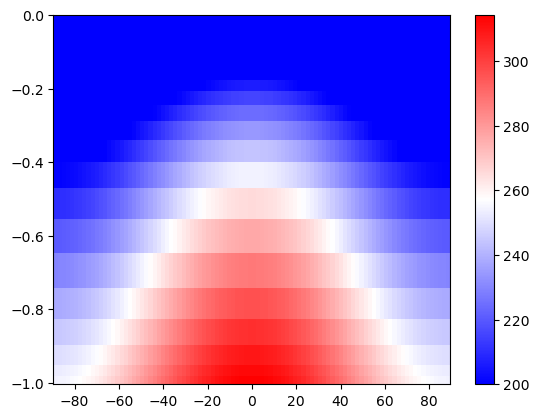

In [23]:
Lat, Zlev = np.meshgrid(lats, -sl)
plt.pcolormesh(Lat, Zlev, temp_gg[:, :, 96], cmap='bwr')
plt.colorbar();

In [15]:
temp_coeffs = dsht(torch.from_numpy(temp_gg))

In [16]:
torch.save(temp_coeffs, preprocess_path+'temp.spectral_RadiativeEquilibrium.pt')
torch.save(temp_gg, preprocess_path+'temp.ggrid_RadiativeEquilibrium.pt')

In [17]:
ps = np.zeros((jmax, imax))
lnps_coeffs = dsht(torch.from_numpy(ps))
torch.save(lnps_coeffs, preprocess_path+'lnps.spectral_RadiativeEquilibrium.pt')
print(['global mean lnps', lnps_coeffs[0, 0]])

['global mean lnps', tensor(0.+0.j, dtype=torch.complex128)]


In [18]:
lnps_coeffs

tensor([[0.+0.j, 0.+0.j, 0.+0.j,  ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j,  ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j,  ..., 0.+0.j, 0.+0.j, 0.+0.j],
        ...,
        [0.+0.j, 0.+0.j, 0.+0.j,  ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j,  ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j,  ..., 0.+0.j, 0.+0.j, 0.+0.j]],
       dtype=torch.complex128)

#### Held and Suarez: 
"If one uses a long relaxation
time everywhere, an unrealistic
thin cold layer develops near the
surface, particularly in the Tropics. The relaxation time is increased in this region to reduce
this effect, but some vestige of this shallow stable
layer still remains in the solutions. This is clearly visible
in the time-mean temperature and potential temperature distribution (Figs. 1c,d) produced by the"G72"
finite-difference model (described below). The potential temperatures also show that the dynamics is
maintaining the static stability well above its radiative
equilibrium value in the extratropics."

In [19]:
# Following Held & Suarez the Newtonian Damping Coefficients are
# latitudinally Dependent. Here we produce those coeffiencients
# and convert into spectral form.
ka = 1.0 / (40.0*86400.0)
ks = 1 / (4.0*86400.0)
slb = 0.7
vert = (sl-slb) / (1.0-slb)
vert = np.where(vert < 0.0, 0.0, vert)
kt = np.zeros((kmax, jmax, imax))
for j in range(jmax):
    for k in range(kmax):
        kt[k, j, :] = ka + (ks - ka)*vert[k]*(coslat[j]**4.0)

cooling_coeffs = dsht(torch.from_numpy(kt))
torch.save(cooling_coeffs, preprocess_path+'cooling.spectral_RadiativeEquilibrium.pt')
torch.save(kt, preprocess_path+'cooling.ggrid_RadiativeEquilibrium.pt')

In [20]:
vert

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.28983323, 0.55562725, 0.76468158, 0.90154547,
       0.97510985])

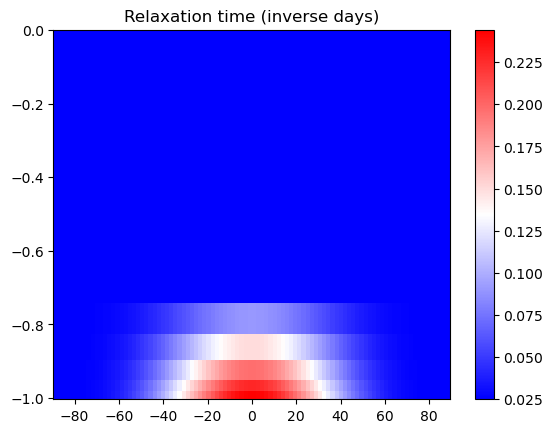

In [108]:
Lat, Zlev = np.meshgrid(lats, -sl)
plt.pcolormesh(Lat, Zlev, kt[:, :, 96]*86400, cmap='bwr')
plt.colorbar(); plt.title('Relaxation time (inverse days)');

In [113]:
from arraylake import Client

client = Client()
client.login()

╭───────────────────────────────── Login ─────────────────────────────────╮                    
                    │                                                                         │                    
                    │          Copy and paste the following ]8;id=3437402;https://earthmover-production.us.auth0.com/activate?user_code=MQZK-BSML\link]8;;\ into your browser:           │                    
                    │                                                                         │                    
                    │ https://earthmover-production.us.auth0.com/activate?user_code=MQZK-BSML │                    
                    │                                                                         │                    
                    │                Ensure the code in your browser matches:                 │                    
                    │                              ╭───────────╮                              │                    
                    │                              │ MQZK-BSML │                              │                    
                    │                              ╰───────────╯                              │                    
                    │                                                                         │                    
                    │         Then follow the instructions in your browser to login.          │                    
                    │                   Visit ]8;id=3437405;https://docs.earthmover.io/setup/org-access#authenticating-as-a-user\docs.earthmover.io]8;;\ for help.                    │                    
                    │                                                                         │                    
                    ╰─────────────────────────────────────────────────────────────────────────╯

Output()

Successfully logged in! Token stored at /Users/bmapes/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: bmapes@miami.edu                                                                                         │
│ Id: 19c3b3f6-c356-48e8-b140-fb41b1a4605e                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [117]:
from arraylake import Client
import zarr

client = Client()
repo = client.get_repo("mpocanes/era5-subscription")
session = repo.readonly_session(branch="main")
root = zarr.open_group(session.store, zarr_format=3, mode="r")

In [122]:
from arraylake import Client
import xarray as xr

client = Client()
repo = client.get_repo("mpocanes/era5-subscription")
session = repo.readonly_session(branch="main")
ds = xr.open_zarr(session.store, zarr_format=3)

ds

TypeError: open_zarr() got unexpected keyword arguments zarr_format

In [124]:
print(xr.__version__)

2023.6.0
